# Model Training & Pickling
### Algerian Forest Fires — Fire Weather Index Prediction

This notebook covers:
- Loading the cleaned data from `eda_data_prep.ipynb`
- Training Linear, Ridge, and Lasso regression models
- Comparing model performance
- Saving the best model and scaler as `.pkl` files

---
## 1. Import Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline

print('All libraries Imported Successfully')


All libraries Imported Successfully


## 2. Load the Cleaned dataset

In [53]:
dataset = pd.read_csv('datasets/algerian_forest_fire_cleaned.csv')

print('Dataset Loaded Successfully')

print('Dataset Shape:', dataset.shape)
print('Dataset Columns:', list(dataset.columns))

Dataset Loaded Successfully
Dataset Shape: (243, 8)
Dataset Columns: ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'ISI', 'FWI']


## 3. Split columns and target

In [54]:
X = dataset.drop('FWI', axis=1)
y = dataset['FWI']

print(f'Features: {X.columns.tolist()}')
print(f'Target: {y.name}')
print(f'Number of Features: {X.shape[1]}')
print(f'Number of Samples: {X.shape[0]}')

Features: ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'ISI']
Target: FWI
Number of Features: 7
Number of Samples: 243


## 4. Train Test Split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training Set Shape: {X_train.shape}')
print(f'Test Set Shape: {X_test.shape}')

Training Set Shape: (194, 7)
Test Set Shape: (49, 7)


## 5. Scale the Features

 Ridge and Lasso penalize large coefficients. If features are on different scales, the penalty becomes unfair. StandardScaler brings everything to mean=0, std=1.

In [56]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit only on train
X_test_scaled  = scaler.transform(X_test)  # transform test with train stats

print('Scaling done')

print(f'Train mean (should be ~0): {X_train_scaled.mean(axis=0).round(3)}')
print(f'Train std (should be 1): {X_train_scaled.std(axis=0).round(3)}')
print(f'\nTest mean: {X_test_scaled.mean(axis=0).round(3)}')
print(f'Test std: {X_test_scaled.std(axis=0).round(3)}')

Scaling done
Train mean (should be ~0): [-0.  0.  0.  0. -0. -0. -0.]
Train std (should be 1): [1. 1. 1. 1. 1. 1. 1.]

Test mean: [-0.052  0.078 -0.235 -0.069 -0.09  -0.199 -0.229]
Test std: [0.967 0.932 1.281 0.778 1.077 0.678 0.75 ]


## 6. Train All Models

In [57]:
lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)

lr.fit(X_train_scaled, y_train)
ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

print('All models trained successfully')

All models trained successfully


## 7. Evaluate Models

In [58]:
def evaluate_model(name, model, X, y):
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    msa = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    print(f'\n{name} - MSE: {mse:.4f}, MAE: {msa:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}')

print('\nModel Evaluation on Test Set:')
evaluate_model('Linear Regression', lr, X_test_scaled, y_test)
evaluate_model('Ridge Regression (alpha=1.0)', ridge, X_test_scaled, y_test)
evaluate_model('Lasso Regression (alpha=1.0)', lasso, X_test_scaled, y_test)


Model Evaluation on Test Set:

Linear Regression - MSE: 0.7876, MAE: 0.5374, RMSE: 0.8874, R²: 0.9740

Ridge Regression (alpha=1.0) - MSE: 0.8123, MAE: 0.5500, RMSE: 0.9013, R²: 0.9732

Lasso Regression (alpha=1.0) - MSE: 1.7260, MAE: 1.0094, RMSE: 1.3138, R²: 0.9431


## 8. Find best Alpha for Ridge regression


Best alpha for Ridge Regression: 0.0010 with R²: 0.9740


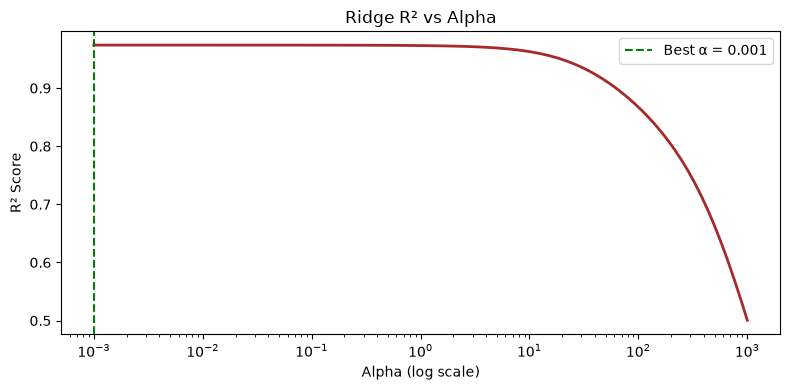

In [59]:
alphas = np.logspace(-3, 3, 100) # from 0.001 to 1000
r2_scores_ridge = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    y_pred = r.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    r2_scores_ridge.append(r2)

best_alpha = alphas[np.argmax(r2_scores_ridge)]
print(f'\nBest alpha for Ridge Regression: {best_alpha:.4f} with R²: {max(r2_scores_ridge):.4f}')


plt.figure(figsize=(8, 4))
plt.semilogx(alphas, r2_scores_ridge, color='brown', linewidth=2)
plt.axvline(best_alpha, color='green', linestyle='--', label=f'Best α = {best_alpha:.3f}')
plt.title('Ridge R² vs Alpha')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R² Score')
plt.legend()
plt.tight_layout()
plt.show()


# 9. Train the final Ridge Model with best Alpha

In [60]:
final_model = Ridge(alpha=best_alpha)
final_model.fit(X_train_scaled, y_train)

y_pred_final = final_model.predict(X_test_scaled)

print('\nFinal Model Evaluation on Test Set:',f'Ridge Regression (alpha={best_alpha:.4f})',sep='\n')

print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_final)):.4f}')
print(f'R²: {r2_score(y_test, y_pred_final):.4f}')
print()


Final Model Evaluation on Test Set:
Ridge Regression (alpha=0.0010)
RMSE: 0.8875
R²: 0.9740



## 10. Actual vs Predicted plot

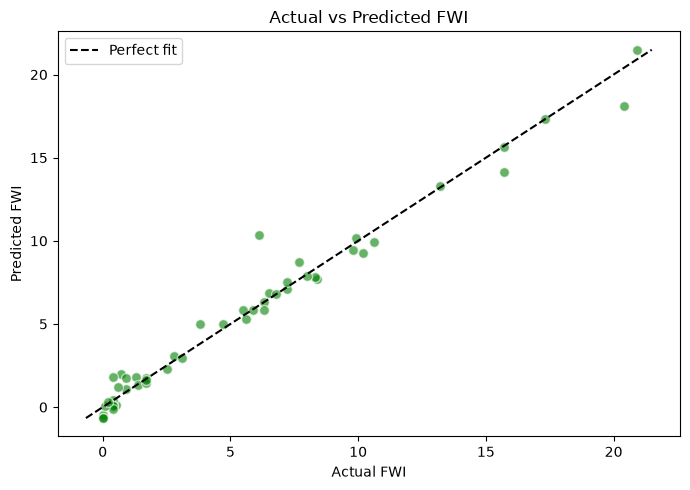

In [61]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_final, alpha=0.6, color='green', edgecolors='white', s=50)
mn = min(y_test.min(), y_pred_final.min())
mx = max(y_test.max(), y_pred_final.max())
plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect fit')
plt.title('Actual vs Predicted FWI')
plt.xlabel('Actual FWI')
plt.ylabel('Predicted FWI')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Residual plot

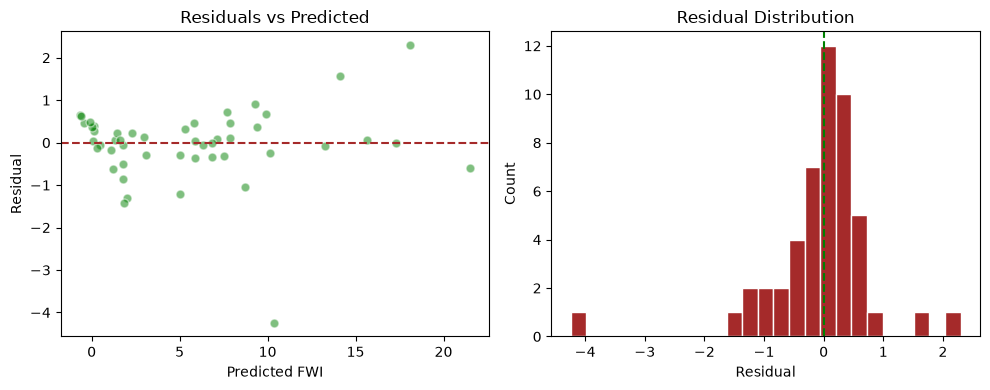

Mean of residuals: -0.0433  (should be close to 0)


In [62]:
residuals = y_test - y_pred_final

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_final, residuals, alpha=0.5, color='green', edgecolors='white', s=40)
plt.axhline(0, color='brown', linestyle='--', linewidth=1.5)
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted FWI')
plt.ylabel('Residual')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=25, color='brown', edgecolor='white')
plt.axvline(0, color='green', linestyle='--', linewidth=1.5)
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Mean of residuals: {residuals.mean():.4f}  (should be close to 0)')

## 12. Coefficient plot

In [63]:
for column, coeff in zip(X.columns, final_model.coef_):
    print(f'Feature: {column}, Coefficient: {coeff:.4f}')

Feature: Temperature, Coefficient: 0.0032
Feature: RH, Coefficient: 0.0940
Feature: Ws, Coefficient: 0.0329
Feature: Rain, Coefficient: -0.0318
Feature: FFMC, Coefficient: -0.5735
Feature: DMC, Coefficient: 3.7984
Feature: ISI, Coefficient: 5.0623


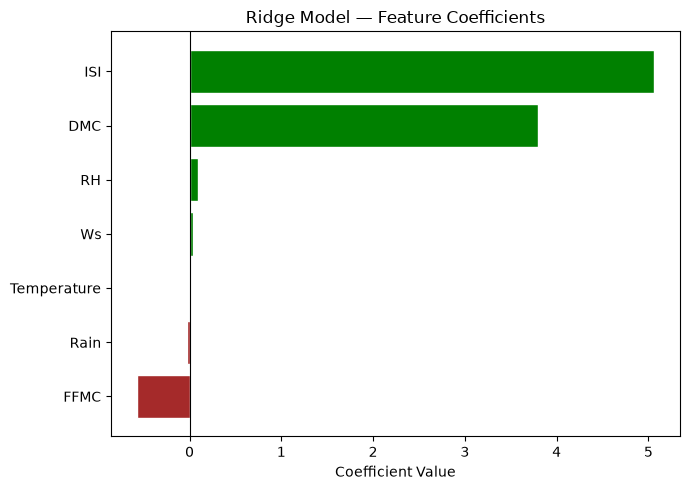

In [64]:
coeff = pd.Series(final_model.coef_, index=X.columns).sort_values()

colors = ['brown' if v < 0 else 'green' for v in coeff]

plt.figure(figsize=(7, 5))
plt.barh(coeff.index, coeff.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Ridge Model — Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 13. Retrain on Full Data & Save pkl Files

 We train on **All** the data, not just the 80% training split. EDA and evaluation done — now model will learn from everything before deploying.

In [65]:
# Fit scaler on all data
prod_scaler = StandardScaler()
X_all_scaled = prod_scaler.fit_transform(X)

# Train Ridge on all data
prod_model = Ridge(alpha=best_alpha)
prod_model.fit(X_all_scaled, y)

print(f'Production model trained on {len(X)} samples')
print(f'Alpha used: {best_alpha:.4f}')

Production model trained on 243 samples
Alpha used: 0.0010


In [66]:
# save model
with open('models/model.pkl', 'wb') as f:
    pickle.dump(prod_model, f)

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(prod_scaler, f)

print('model.pkl and scaler.pkl saved in models/ folder')

model.pkl and scaler.pkl saved in models/ folder
